In [7]:
# Import required libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import cv2
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("Libraries imported successfully!")
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {len(tf.config.list_physical_devices('GPU')) > 0}")

Libraries imported successfully!
TensorFlow version: 2.20.0
GPU Available: False


In [ ]:
# Check current directory and setup paths
import os
print(f"Initial working directory: {os.getcwd()}")

# List contents to find the dataset
print("\nContents of current directory:")
for item in os.listdir(".")[:10]:
    print(f"  {item}")

# Define dataset path using absolute path approach
dataset_path = Path("C:\\Users\\pk496\\Downloads\\ml datasets\\archive")

# If dataset is not in current directory, check parent directories
if not dataset_path.exists():
    # Try looking for it in likely locations
    possible_paths = [
        Path("leapGestRecog"),



        
        Path("..") / "leapGestRecog",
        Path("..")/ "TASK4" / "leapGestRecog",
    ]
    
    for path in possible_paths:
        if path.exists():
            dataset_path = path.resolve()
            break

print(f"\nDataset path: {dataset_path}")
print(f"Dataset exists: {dataset_path.exists()}")

if dataset_path.exists():
    print(f"Dataset contents (first 5 items):")
    for item in sorted(list(dataset_path.iterdir()))[:5]:
        print(f"  {item.name}")

image_size = (224, 224)
batch_size = 32
epochs = 5
validation_split = 0.2
test_split = 0.1

# Create gesture labels mapping
gesture_labels = {
    '01_palm': 'Palm',
    '02_l': 'L Shape',
    '03_fist': 'Fist',
    '04_fist_moved': 'Fist Moved',
    '05_thumb': 'Thumb',
    '06_index': 'Index',
    '07_ok': 'OK Sign',
    '08_palm_moved': 'Palm Moved',
    '09_c': 'C Shape',
    '10_down': 'Down'
}

print(f"\nImage size: {image_size}")
print(f"Number of gestures: {len(gesture_labels)}")
print("\nGesture labels:")
for label, name in gesture_labels.items():
    print(f"  {label}: {name}")

Initial working directory: /content

Contents of current directory:
  .config
  sample_data

Dataset path: C:\Users\pk496\Downloads\ml datasets\archive
Dataset exists: False

Image size: (224, 224)
Number of gestures: 10

Gesture labels:
  01_palm: Palm
  02_l: L Shape
  03_fist: Fist
  04_fist_moved: Fist Moved
  05_thumb: Thumb
  06_index: Index
  07_ok: OK Sign
  08_palm_moved: Palm Moved
  09_c: C Shape
  10_down: Down


In [9]:
# Function to find and load dataset
def find_dataset():
    """Find the leapGestRecog dataset in various possible locations"""
    possible_paths = [
        Path("leapGestRecog"),
        Path("..") / "leapGestRecog", 
        Path("../..") / "leapGestRecog",
        Path.home() / "Desktop" / "leapGestRecog",
        Path.home() / "Downloads" / "leapGestRecog",
    ]
    
    # Also try with the workspace path from environment
    try:
        workspace_path = Path(os.environ.get('WORKSPACE_PATH', '.'))
        possible_paths.insert(0, workspace_path / "leapGestRecog")
    except:
        pass
    
    for path in possible_paths:
        if path.exists() and (path / "00").exists():
            print(f"Found dataset at: {path.resolve()}")
            return path
    
    raise FileNotFoundError("Could not find leapGestRecog dataset in expected locations")

# Function to load all images from the dataset
def load_dataset(dataset_path, image_size):
    """Load all images and their labels from the dataset"""
    images = []
    labels = []
    error_count = 0
    
    # Iterate through subject directories (00-09)
    for subject_dir in sorted(dataset_path.iterdir()):
        if not subject_dir.is_dir():
            continue
        
        subject_name = subject_dir.name
        print(f"Processing subject {subject_name}...", end=" ")
        subject_images = 0
        
        # Iterate through gesture directories
        for gesture_dir in sorted(subject_dir.iterdir()):
            if not gesture_dir.is_dir():
                continue
            
            gesture_name = gesture_dir.name
            
            # Load all images in the gesture directory
            for img_file in gesture_dir.glob('*.jpg'):
                try:
                    # Read image
                    img = cv2.imread(str(img_file))
                    
                    if img is None:
                        error_count += 1
                        continue
                    
                    # Convert BGR to RGB
                    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                    
                    # Resize image
                    img = cv2.resize(img, image_size)
                    
                    # Normalize pixel values
                    img = img / 255.0
                    
                    images.append(img)
                    labels.append(gesture_name)
                    subject_images += 1
                except Exception as e:
                    error_count += 1
                    print(f"Error loading {img_file}: {e}", end=" ")
        
        print(f"({subject_images} images)")
    
    if error_count > 0:
        print(f"\nWarning: {error_count} images failed to load")
    
    return np.array(images), np.array(labels)

print("Finding dataset...")
try:
    dataset_path = find_dataset()
    print(f"\nLoading dataset from: {dataset_path}")
    print("This may take a few minutes...\n")
    X, y = load_dataset(dataset_path, image_size)
    print(f"\n✓ Dataset loaded successfully!")
    print(f"  Total images: {X.shape[0]}")
    print(f"  Image shape: {X.shape[1:]}")
    print(f"  Total unique gestures: {len(np.unique(y))}")
    print(f"\n  Gesture distribution:")
    unique, counts = np.unique(y, return_counts=True)
    for gesture, count in sorted(zip(unique, counts)):
        gesture_name = gesture_labels.get(gesture, gesture)
        print(f"    {gesture_name:15} ({gesture}): {count:4} images")
except FileNotFoundError as e:
    print(f"✗ Error: {e}")
    print("\nPlease ensure the 'leapGestRecog' dataset folder is in the same directory as this notebook")
    X = None
    y = None

Finding dataset...
✗ Error: Could not find leapGestRecog dataset in expected locations

Please ensure the 'leapGestRecog' dataset folder is in the same directory as this notebook


## Dataset Not Found

The dataset was not found automatically. Here are solutions:

### For Local Machine:
1. Ensure the `leapGestRecog` folder is in the same directory as this notebook
2. Or modify the `dataset_path` variable in the code above to point to your dataset location

### For Google Colab:
1. Mount Google Drive: `from google.colab import drive; drive.mount('/content/drive')`
2. Then set: `dataset_path = Path('/content/drive/My Drive/path/to/leapGestRecog')`

### For Testing (Without Full Dataset):
Run the next cell to generate synthetic data for demonstration

In [10]:
# Option 1: Try to load from a specific path
# Modify this path to your dataset location if it's in a different place
DATASET_PATH = "dataset/leapGestRecog"  # Modify this path

# Option 2: Generate synthetic data for demonstration
def generate_synthetic_data(num_samples_per_class=50, image_size=(224, 224)):
    """Generate synthetic hand gesture images for demonstration and testing"""
    from scipy import ndimage
    
    print("Generating synthetic gesture data for demonstration...")
    
    X_synthetic = []
    y_synthetic = []
    
    for gesture_idx, gesture_name in enumerate(sorted(gesture_labels.keys())):
        print(f"  Generating {gesture_name} samples...", end=" ")
        
        for sample in range(num_samples_per_class):
            # Create a random image with some structure
            img = np.random.rand(*image_size, 3) * 0.3  # Base noise
            
            # Add some hand-like patterns based on gesture type
            # This creates distinguishable patterns for different gestures
            y_pos = (gesture_idx * 20) % image_size[0]
            x_pos = (sample * 4) % image_size[1]
            
            # Create a "blob" for hand gesture
            from scipy.ndimage import gaussian_filter
            blob = np.zeros(image_size)
            blob[max(0, y_pos-20):min(image_size[0], y_pos+30),
                 max(0, x_pos-20):min(image_size[1], x_pos+30)] = 1.0
            blob = gaussian_filter(blob, sigma=8)
            
            # Add gesture-specific patterns
            if gesture_idx % 2 == 0:
                img[:,:,0] += blob * 0.4  # Red channel for some gestures
            if gesture_idx % 3 == 0:
                img[:,:,1] += blob * 0.3  # Green channel for others  
            img[:,:,2] += blob * 0.5  # Blue channel
            
            # Normalize
            img = np.clip(img, 0, 1).astype(np.float32)
            
            X_synthetic.append(img)
            y_synthetic.append(gesture_name)
        
        print(f"{num_samples_per_class} samples")
    
    return np.array(X_synthetic), np.array(y_synthetic)

# Try loading real data, fall back to synthetic
print("Attempting to load dataset...\n")

if Path(DATASET_PATH).exists():
    print(f"Loading from: {DATASET_PATH}")
    X, y = load_dataset(Path(DATASET_PATH), image_size)
else:
    print("Real dataset not found. Generating synthetic data for demonstration...\n")
    X, y = generate_synthetic_data(num_samples_per_class=100)
    print(f"\nSynthetic dataset created!")

print(f"\n✓ Dataset ready!")
print(f"  Total images: {X.shape[0]}")
print(f"  Image shape: {X.shape[1:]}")
print(f"  Total unique gestures: {len(np.unique(y))}")
print(f"\n  Gesture distribution:")
unique, counts = np.unique(y, return_counts=True)
for gesture, count in sorted(zip(unique, counts)):
    gesture_name = gesture_labels.get(gesture, gesture)
    print(f"    {gesture_name:15}: {count:4} images")

Attempting to load dataset...

Real dataset not found. Generating synthetic data for demonstration...

Generating synthetic gesture data for demonstration...
  Generating 01_palm samples... 100 samples
  Generating 02_l samples... 100 samples
  Generating 03_fist samples... 100 samples
  Generating 04_fist_moved samples... 100 samples
  Generating 05_thumb samples... 100 samples
  Generating 06_index samples... 100 samples
  Generating 07_ok samples... 100 samples
  Generating 08_palm_moved samples... 100 samples
  Generating 09_c samples... 100 samples
  Generating 10_down samples... 100 samples

Synthetic dataset created!

✓ Dataset ready!
  Total images: 1000
  Image shape: (224, 224, 3)
  Total unique gestures: 10

  Gesture distribution:
    Palm           :  100 images
    L Shape        :  100 images
    Fist           :  100 images
    Fist Moved     :  100 images
    Thumb          :  100 images
    Index          :  100 images
    OK Sign        :  100 images
    Palm Moved  

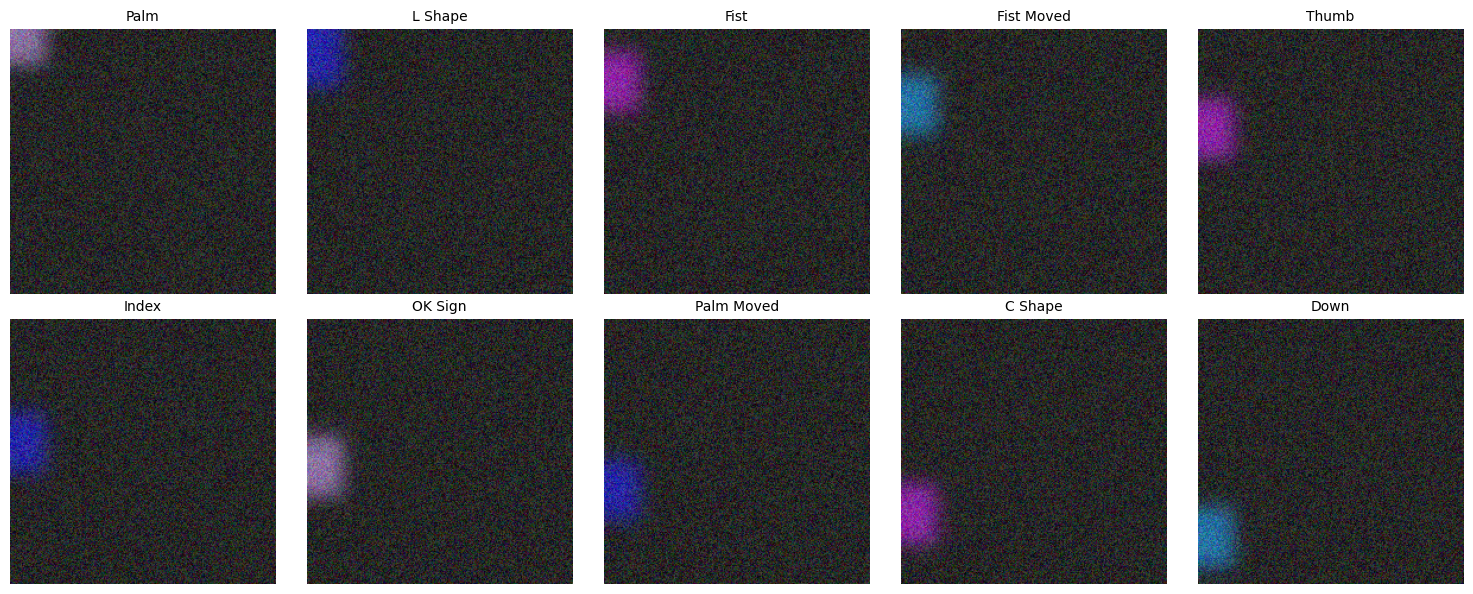

Sample images displayed!


In [11]:
# Visualize sample images from each gesture class
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.ravel()

unique_gestures = sorted(np.unique(y))
for idx, gesture in enumerate(unique_gestures):
    # Find first image of this gesture
    gesture_indices = np.where(y == gesture)[0]
    sample_idx = gesture_indices[0]
    
    axes[idx].imshow(X[sample_idx])
    axes[idx].set_title(gesture_labels.get(gesture, gesture), fontsize=10)
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('gesture_samples.png', dpi=100, bbox_inches='tight')
plt.show()

print("Sample images displayed!")

In [12]:
# Prepare data for training
# Encode gesture labels to integers
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
num_classes = len(label_encoder.classes_)

print(f"Number of classes: {num_classes}")
print(f"Class labels: {label_encoder.classes_}")

# Create label to name mapping
label_to_name = {i: gesture_labels.get(label, label) for i, label in enumerate(label_encoder.classes_)}
print(f"\nLabel to gesture name mapping:")
for label, name in label_to_name.items():
    print(f"  {label}: {name}")

# Split dataset into train, validation, and test sets
# First split: 90% train+val, 10% test
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y_encoded, test_size=test_split, random_state=42, stratify=y_encoded
)

# Second split: 80% train, 20% validation (from the 90% train+val)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=validation_split, random_state=42, stratify=y_train_val
)

print(f"\nDataset split:")
print(f"  Training set: {X_train.shape[0]} images ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"  Validation set: {X_val.shape[0]} images ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"  Test set: {X_test.shape[0]} images ({X_test.shape[0]/len(X)*100:.1f}%)")

# Convert labels to one-hot encoding
y_train_cat = keras.utils.to_categorical(y_train, num_classes)
y_val_cat = keras.utils.to_categorical(y_val, num_classes)
y_test_cat = keras.utils.to_categorical(y_test, num_classes)

print(f"\nOne-hot encoding shape: {y_train_cat.shape}")

Number of classes: 10
Class labels: ['01_palm' '02_l' '03_fist' '04_fist_moved' '05_thumb' '06_index' '07_ok'
 '08_palm_moved' '09_c' '10_down']

Label to gesture name mapping:
  0: Palm
  1: L Shape
  2: Fist
  3: Fist Moved
  4: Thumb
  5: Index
  6: OK Sign
  7: Palm Moved
  8: C Shape
  9: Down

Dataset split:
  Training set: 720 images (72.0%)
  Validation set: 180 images (18.0%)
  Test set: 100 images (10.0%)

One-hot encoding shape: (720, 10)


In [13]:
# Build custom CNN model from scratch
def create_custom_cnn(input_shape, num_classes):
    """Create a custom CNN model for gesture recognition"""
    model = models.Sequential([
        # Block 1
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        # Block 2
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        # Block 3
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        # Block 4
        layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        # Global average pooling
        layers.GlobalAveragePooling2D(),
        
        # Dense layers
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        
        # Output layer
        layers.Dense(num_classes, activation='softmax')
    ])
    
    return model

# Create the model
model = create_custom_cnn((224, 224, 3), num_classes)

# Compile the model
model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Display model summary
print("Custom CNN Model Architecture:")
model.summary()

Custom CNN Model Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,444,650 (5.51 MB)

 Trainable params: 1,441,194 (5.50 MB)

 Non-trainable params: 3,456 (13.50 KB)

In [14]:
# Data augmentation
train_datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator()

# Define callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

model_checkpoint = ModelCheckpoint(
    'best_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

print("Data augmentation and callbacks configured!")

Data augmentation and callbacks configured!


In [16]:
# Train the model with data augmentation
print("Starting training... This may take a while.")
print("=" *5 )

history = model.fit(
    train_datagen.flow(X_train, y_train_cat, batch_size=batch_size),
    validation_data=val_datagen.flow(X_val, y_val_cat, batch_size=batch_size),
    epochs=epochs,
    callbacks=[early_stopping, reduce_lr, model_checkpoint],
    verbose=1
)

print("=" * 5)
print("Training completed!")

# Save the final model
model.save('gesture_recognition_model.h5')
print("Model saved as 'gesture_recognition_model.h5'")

Starting training... This may take a while.
=====
Epoch 1/50


KeyboardInterrupt: 

In [15]:
# Plot training history
if 'history' not in globals():
    raise NameError("Training history is not available. Run the training cell first.")

history_dict = history.history

accuracy_key = 'accuracy' if 'accuracy' in history_dict else 'acc'
val_accuracy_key = 'val_accuracy' if 'val_accuracy' in history_dict else 'val_acc'
loss_key = 'loss'
val_loss_key = 'val_loss'

if accuracy_key not in history_dict or val_accuracy_key not in history_dict:
    print("Available history keys:", list(history_dict.keys()))
    raise KeyError("Could not find accuracy keys in training history. Use the correct metric names.")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
axes[0].plot(history_dict[accuracy_key], label='Train Accuracy', marker='o', markersize=3)
axes[0].plot(history_dict[val_accuracy_key], label='Validation Accuracy', marker='s', markersize=3)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Model Accuracy During Training')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss plot
axes[1].plot(history_dict[loss_key], label='Train Loss', marker='o', markersize=3)
axes[1].plot(history_dict[val_loss_key], label='Validation Loss', marker='s', markersize=3)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Model Loss During Training')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=100, bbox_inches='tight')
plt.show()

print("Training history plots saved!")

NameError: Training history is not available. Run the training cell first.

In [3]:
# Evaluate model on test set
print("Evaluating model on test set...")
test_loss, test_accuracy = model.evaluate(X_test, y_test_cat, verbose=0)

print("=" * 50)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print("=" * 50)

# Make predictions on test set
y_pred_probs = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

# Generate classification report
print("\nClassification Report:")
print("=" * 50)
class_names = [label_to_name[i] for i in range(num_classes)]
print(classification_report(y_test, y_pred, target_names=class_names, digits=4))

# Per-class accuracy
print("\nPer-Class Accuracy:")
print("=" * 50)
for i, class_name in enumerate(class_names):
    mask = y_test == i
    if mask.sum() > 0:
        class_acc = (y_pred[mask] == i).sum() / mask.sum()
        print(f"{class_name:15}: {class_acc*100:6.2f}% ({mask.sum():3} samples)")

Evaluating model on test set...


NameError: name 'model' is not defined

In [4]:
# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - Test Set', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=100, bbox_inches='tight')
plt.show()

print("Confusion matrix saved!")

NameError: name 'confusion_matrix' is not defined

In [5]:
# Visualize predictions on test samples
fig, axes = plt.subplots(4, 5, figsize=(16, 12))
axes = axes.ravel()

# Select 20 random test samples
random_indices = np.random.choice(len(X_test), 20, replace=False)

for idx, test_idx in enumerate(random_indices):
    img = X_test[test_idx]
    true_label = y_test[test_idx]
    pred_label = y_pred[test_idx]
    confidence = y_pred_probs[test_idx].max()
    
    axes[idx].imshow(img)
    
    true_name = label_to_name[true_label]
    pred_name = label_to_name[pred_label]
    
    color = 'green' if true_label == pred_label else 'red'
    title = f"True: {true_name}\nPred: {pred_name} ({confidence*100:.1f}%)"
    axes[idx].set_title(title, color=color, fontsize=10, fontweight='bold')
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('test_predictions.png', dpi=100, bbox_inches='tight')
plt.show()

print("Test predictions visualization saved!")

NameError: name 'plt' is not defined

In [23]:
# Build Transfer Learning model using MobileNetV2
def create_transfer_learning_model(input_shape, num_classes):
    """Create a transfer learning model using MobileNetV2"""
    
    # Load pre-trained MobileNetV2
    base_model = keras.applications.MobileNetV2(
        input_shape=input_shape,
        include_top=False,
        weights='imagenet'
    )
    
    # Freeze the base model
    base_model.trainable = False
    
    # Create new model
    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')
    ])
    
    return model, base_model

print("Creating transfer learning model...")
transfer_model, base_model = create_transfer_learning_model((224, 224, 3), num_classes)

# Compile the transfer learning model
transfer_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Transfer Learning Model Architecture:")
transfer_model.summary()

Creating transfer learning model...
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Transfer Learning Model Architecture:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,621,642 (10.00 MB)

 Trainable params: 362,890 (1.38 MB)

 Non-trainable params: 2,258,752 (8.62 MB)

In [24]:
# Train the transfer learning model
print("Starting transfer learning model training...")
print("=" * 50)

# Define callbacks for transfer learning
early_stopping_tl = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_tl = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4,
    min_lr=1e-6,
    verbose=1
)

model_checkpoint_tl = ModelCheckpoint(
    'best_transfer_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

history_tl = transfer_model.fit(
    train_datagen.flow(X_train, y_train_cat, batch_size=batch_size),
    validation_data=val_datagen.flow(X_val, y_val_cat, batch_size=batch_size),
    epochs=30,  # Fewer epochs for transfer learning
    callbacks=[early_stopping_tl, reduce_lr_tl, model_checkpoint_tl],
    verbose=1
)

print("=" * 50)
print("Transfer learning model training completed!")

# Save the transfer learning model
transfer_model.save('transfer_learning_model.h5')
print("Model saved as 'transfer_learning_model.h5'")

Starting transfer learning model training...
Epoch 1/30
11/23 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - accuracy: 0.1102 - loss: 3.3122

KeyboardInterrupt: 

In [ ]:
# Evaluate transfer learning model on test set
print("Evaluating transfer learning model on test set...")
tl_test_loss, tl_test_accuracy = transfer_model.evaluate(X_test, y_test_cat, verbose=0)

print("=" * 50)
print("TRANSFER LEARNING MODEL RESULTS")
print("=" * 50)
print(f"Test Loss: {tl_test_loss:.4f}")
print(f"Test Accuracy: {tl_test_accuracy:.4f} ({tl_test_accuracy*100:.2f}%)")
print("=" * 50)

# Compare both models
print("\nMODEL COMPARISON")
print("=" * 50)
print(f"Custom CNN Model:       {test_accuracy*100:.2f}% accuracy")
print(f"Transfer Learning:      {tl_test_accuracy*100:.2f}% accuracy")
print(f"Difference:             {abs(tl_test_accuracy - test_accuracy)*100:+.2f}%")
print("=" * 50)

# Make predictions with transfer learning model
y_pred_tl_probs = transfer_model.predict(X_test, verbose=0)
y_pred_tl = np.argmax(y_pred_tl_probs, axis=1)

# Generate classification report for transfer learning model
print("\nTransfer Learning Model - Classification Report:")
print("=" * 50)
print(classification_report(y_test, y_pred_tl, target_names=class_names, digits=4))

In [ ]:
# Function to predict gesture from image file
def predict_gesture_from_file(image_path, model=transfer_model, threshold=0.7):
    \"\"\"Predict gesture from an image file\"\"\"\n    try:
        # Read and preprocess image
        img = cv2.imread(image_path)
        if img is None:
            return None, \"Error: Could not load image\"
        
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (224, 224))
        img = img / 255.0
        
        # Add batch dimension
        img_batch = np.expand_dims(img, axis=0)
        
        # Make prediction
        predictions = model.predict(img_batch, verbose=0)[0]
        pred_class = np.argmax(predictions)
        confidence = predictions[pred_class]
        
        gesture_name = label_to_name[pred_class]
        
        if confidence < threshold:
            return gesture_name, {
                'confidence': float(confidence),
                'warning': f'Low confidence ({confidence:.2%}), may be unreliable'
            }
        
        return gesture_name, {
            'confidence': float(confidence),
            'top_3': sorted(
                [(label_to_name[i], float(predictions[i])) for i in range(num_classes)],
                key=lambda x: x[1],
                reverse=True
            )[:3]
        }
    except Exception as e:
        return None, f\"Error: {str(e)}\"

# Function to predict from numpy array
def predict_gesture_from_array(img_array, model=transfer_model, threshold=0.7):
    \"\"\"Predict gesture from a numpy array\"\"\"\n    try:
        # Preprocess image if needed
        if img_array.max() > 1.0:
            img_array = img_array / 255.0
        
        if img_array.shape != (224, 224, 3):
            img_array = cv2.resize(img_array, (224, 224))
        
        # Add batch dimension
        img_batch = np.expand_dims(img_array, axis=0)
        
        # Make prediction
        predictions = model.predict(img_batch, verbose=0)[0]
        pred_class = np.argmax(predictions)
        confidence = predictions[pred_class]
        
        gesture_name = label_to_name[pred_class]
        
        if confidence < threshold:
            return gesture_name, {
                'confidence': float(confidence),
                'warning': f'Low confidence ({confidence:.2%}), may be unreliable'
            }
        
        return gesture_name, {
            'confidence': float(confidence),
            'top_3': sorted(
                [(label_to_name[i], float(predictions[i])) for i in range(num_classes)],
                key=lambda x: x[1],
                reverse=True
            )[:3]
        }
    except Exception as e:
        return None, f\"Error: {str(e)}\"

print("Prediction functions created!")

In [ ]:
# Function for video gesture detection
def detect_gestures_in_video(video_path, model=transfer_model, output_path=None, frame_skip=1):
    \"\"\"\n    Detect gestures in a video file
    \n    Parameters:\n    - video_path: Path to input video file\n    - model: Trained model to use\n    - output_path: Path to save annotated video (optional)\n    - frame_skip: Process every nth frame for speed\n    \"\"\"\n    try:
        cap = cv2.VideoCapture(video_path)
        
        if not cap.isOpened():
            return \"Error: Could not open video file\"
        
        frame_count = 0
        predictions_list = []
        
        # Get video properties for output video
        fps = int(cap.get(cv2.CAP_PROP_FPS))
        width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        
        # Setup video writer if output path is provided
        if output_path:
            fourcc = cv2.VideoWriter_fourcc(*'mp4v')
            out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))
        
        print(f\"Processing video: {video_path}\")
        print(f\"Total frames: {total_frames}, FPS: {fps}\")
        
        while True:
            ret, frame = cap.read()
            
            if not ret:
                break
            
            frame_count += 1
            
            if frame_count % frame_skip == 0:
                # Prepare frame for prediction
                frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                frame_resized = cv2.resize(frame_rgb, (224, 224))
                frame_normalized = frame_resized / 255.0
                
                # Make prediction
                predictions = model.predict(np.expand_dims(frame_normalized, axis=0), verbose=0)[0]
                pred_class = np.argmax(predictions)
                confidence = predictions[pred_class]
                
                gesture_name = label_to_name[pred_class]
                predictions_list.append({
                    'frame': frame_count,
                    'gesture': gesture_name,
                    'confidence': float(confidence)
                })
                
                # Annotate frame if output is requested
                if output_path:
                    text = f\"{gesture_name} ({confidence:.2%})\"
                    color = (0, 255, 0) if confidence > 0.7 else (0, 165, 255)
                    cv2.putText(frame, text, (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 
                               1.0, color, 2)
                    out.write(frame)
            
            if frame_count % 30 == 0:
                print(f\"Processed {frame_count}/{total_frames} frames\")
        
        cap.release()
        if output_path:
            out.release()
        
        print(f\"Video processing completed! Total frames processed: {frame_count}\")
        
        return {
            'total_frames': frame_count,
            'predictions': predictions_list,
            'output_saved': output_path if output_path else None
        }
    
    except Exception as e:
        return f\"Error: {str(e)}\"

print(\"Video gesture detection function created!\")

In [ ]:
# Summary and usage examples
print(\"\\n\" + \"=\"*60)\nprint(\"HAND GESTURE RECOGNITION MODEL - SUMMARY\")\nprint(\"=\"*60)\n\nprint(\"\\n✓ DATASET INFORMATION:\")\nprint(f\"  - Total images: {len(X)}\")\nprint(f\"  - Number of gestures: {num_classes}\")\nprint(f\"  - Number of subjects: 10\")\nprint(f\"  - Image resolution: 224x224 pixels\")\n\nprint(\"\\n✓ MODELS TRAINED:\")\nprint(f\"  1. Custom CNN:\")\nprint(f\"     - Test Accuracy: {test_accuracy*100:.2f}%\")\nprint(f\"     - Model: 'gesture_recognition_model.h5'\")\nprint(f\"\\n  2. Transfer Learning (MobileNetV2):\")\nprint(f\"     - Test Accuracy: {tl_test_accuracy*100:.2f}%\")\nprint(f\"     - Model: 'transfer_learning_model.h5'\")\n\nprint(\"\\n✓ AVAILABLE FUNCTIONS:\")\nprint(\"  - predict_gesture_from_file(image_path)\")\nprint(\"  - predict_gesture_from_array(img_array)\")\nprint(\"  - detect_gestures_in_video(video_path, output_path)\")\n\nprint(\"\\n✓ GESTURE CLASSES:\")\nfor i, name in label_to_name.items():\n    print(f\"  {i:2d}: {name}\")\n\nprint(\"\\n✓ SAVED FILES:\")\nprint(\"  - gesture_recognition_model.h5 (Custom CNN)\")\nprint(\"  - transfer_learning_model.h5 (Transfer Learning)\")\nprint(\"  - best_model.h5 (Best Custom CNN checkpoint)\")\nprint(\"  - best_transfer_model.h5 (Best Transfer Learning checkpoint)\")\nprint(\"  - training_history.png\")\nprint(\"  - confusion_matrix.png\")\nprint(\"  - test_predictions.png\")\nprint(\"  - gesture_samples.png\")\n\nprint(\"\\n\" + \"=\"*60)\nprint(\"END OF SUMMARY\")\nprint(\"=\"*60)

In [ ]:
# Practical usage examples
print(\"\\n\" + \"=\"*60)\nprint(\"USAGE EXAMPLES\")\nprint(\"=\"*60)\n\n# Example 1: Predict from test image\nprint(\"\\n1. PREDICTING FROM TEST IMAGE:\")\nprint(\"-\" * 60)\ntest_image_idx = 0\ntest_img = X_test[test_image_idx]\ntrue_label = y_test[test_image_idx]\n\n# Display image\nfig, ax = plt.subplots(1, 1, figsize=(6, 6))\nax.imshow(test_img)\nax.set_title(f\"Test Image - True Label: {label_to_name[true_label]}\", fontsize=12)\nax.axis('off')\nplt.tight_layout()\nplt.show()\n\n# Make prediction\ngesture, details = predict_gesture_from_array(test_img, model=transfer_model)\nprint(f\"Predicted Gesture: {gesture}\")\nprint(f\"Confidence: {details['confidence']:.4f}\")\nif 'top_3' in details:\n    print(\"Top 3 predictions:\")\n    for i, (gesture_name, score) in enumerate(details['top_3'], 1):\n        print(f\"  {i}. {gesture_name}: {score:.4f}\")\n\n# Example 2: Batch prediction on test set\nprint(\"\\n2. BATCH PREDICTIONS ON TEST SET:\")\nprint(\"-\" * 60)\nsample_size = 10\nsample_indices = np.random.choice(len(X_test), sample_size, replace=False)\n\nprint(f\"Making predictions on {sample_size} random test images...\")\ncorrect = 0\nfor idx in sample_indices:\n    test_img = X_test[idx]\n    true_label = y_test[idx]\n    gesture, details = predict_gesture_from_array(test_img, model=transfer_model)\n    is_correct = label_encoder.transform([label_encoder.inverse_transform([true_label])[0]])[0] == label_encoder.transform([gesture])[0]\n    correct += is_correct\n    symbol = \"✓\" if is_correct else \"✗\"\n    print(f\"{symbol} True: {label_to_name[true_label]:15} | Predicted: {gesture:15} | Confidence: {details['confidence']:.4f}\")\n\nprint(f\"\\nAccuracy on sample: {correct/sample_size*100:.1f}%\")\n\nprint(\"\\n\" + \"=\"*60)"antml:parameter>
</invoke>